# Individuality dimensions with LDA — shrinkage variant

Mouse identification from syllable composition, and the LD1/LD2 embedding that follows from
it. Three outputs and nothing else: the leave-one-session-out score, the 2D scatter of mice
in discriminant space, and the per-feature correlation profiles.

## Why there is no PCA step

LDA whitens by the within-class scatter $S_W$, which it estimates from

$$\text{within-class df} = n_\text{training sessions} - n_\text{mice}$$

For 56 mice at `N_PER_MOUSE = 3` that is $168 - 56 = 112$. Keep the feature count **below**
that and $S_W$ is invertible, the LDA optimum is unique, and the score is a property of the
data. Go above it and $S_W$ is singular: a whole subspace of solutions is equally optimal,
and the implementation picks one by truncating numerically in whatever basis you handed it.

That is not a subtlety. Rotating the feature axes cannot change an LDA answer — it moves no
data, only relabels the axes — so any change in score is the implementation choosing a
different solution. Measured on this dataset, over 4 random bases:

| representation | score | spread | |
|---|---|---|---|
| PCA 25 | 0.837 | 0.000 | well posed |
| PCA 40 | 0.850 | 0.000 | well posed |
| PCA 100 | 0.606 | 0.000 | well posed |
| PCA 200 | 0.042 → 0.833 | **0.790** | meaningless |
| raw 360 | 0.829 → 0.848 | **0.019** | meaningless |

So the PCA component count was never a tuning preference; it was what kept the problem
solvable, and the old pipeline had no guard that used the right $n$. Shrinkage solves the
same problem directly: mix the measured $S_W$ with a scaled identity, so no direction can
read as zero within-mouse variance and the solution is unique at any feature count.

| representation | score | spread | |
|---|---|---|---|
| raw 360, shrinkage = 0.3 | 0.885 | 0.000 | well posed |
| raw 360, shrinkage = 0.5 | 0.873 | 0.000 | well posed |

sklearn's `shrinkage='auto'` (Ledoit-Wolf) is deliberately **not** used: its shrinkage
intensity is estimated from per-coordinate fourth moments, which are basis dependent, and it
measures a spread of 0.012 where a fixed value gives exactly 0.000.

**The shrinkage value is chosen by nested CV, never by reading the score below.** Picking it
on the same leave-one-out score you then report is selection bias, and it is worth about
+0.03 here. The inner loop sees only the outer fold's training sessions.

In [1]:
# ---- DATA FILTERING ---------------------------------------------------------------
QC_STRICTNESS = 'filtered_out'
# Which sessions the curated QC sheet removes (session_filters.exclusions_by_timepoint):
#   'filtered_out'            -> 'Used in paper' == 'filtered out'      (12 sessions)
#   'filtered_out_and_revise' -> those PLUS 'need to revise'            (21 sessions)

MAX_SESSION_MISSING = 0.1
# Drop sessions with more than this fraction of NaN bins. None keeps every session.
# At 0.1 this costs 8 sessions and 2 mice (CSH_ZAD_026, NYU-30), both right-paw tracking
# dropouts. Below ~1% it stops screening artifacts and starts screening ordinary sessions.

MIN_SESSIONS_PER_MOUSE = 3
# A mouse needs at least this many surviving sessions to stay a class. Applied AFTER the
# other screens, so raising MAX_SESSION_MISSING can remove a mouse without naming it.

DROP_INCOMPLETE_TRIALS = False
# Trial-level screen: drop any trial with a missing bin in any of its four epochs, rather
# than letting the per-session mean skip it. The honest test of whether missing data
# biases the features, since no mouse and no session leaves. Reproduces LD1 at |r| = 0.994.

SYLLABLE_CHANNELS = ('paw', 'whisk', 'lick')
# Any subset. A syllable is (paw state, whisking on/off, licking on/off) and binarize()
# lays each timestep out as 7 paw one-hot columns (state 1 is the dropped reference) +
# whisk + lick, so a channel is a clean column subset.
#
#   channels             feat    lab var   mouse ID   lab from held-out mouse
#   paw + whisk + lick    360      0.166     0.848          0.398
#   paw + whisk           320      0.114     0.794          0.297
#   paw only              280      0.042     0.736          0.234
#
# Paw-only is the only subset with no detectable lab effect (p = 0.111) and still
# identifies the mouse at 0.736 of 56. Changing this changes the feature space, so LD1
# from a paw-only run is not the LD1 quoted elsewhere -- refit every correlate.

# ---- LAB VARIANCE -----------------------------------------------------------------
LAB_CORRECTION = 'none'      # 'none' | 'center' | 'zscore'
# Applied to the session x feature matrix before the LDA, by functions.remove_lab_variance.
# READ THIS BEFORE TURNING IT ON. Lab is NESTED INSIDE MOUSE, so this is not a nuisance
# regressor that leaves the signal intact: after centring, the corrected mouse means within
# a lab sum to zero and mouse identity loses one dimension per lab (10 of 55 here). Expect
# the score to fall, and to fall further for mice in small labs. The honest use is a
# COMPARISON -- run 'none' and 'center' and report both. What survives is individuality not
# explained by lab; what does not is either lab nuisance or lab-linked individuality, and
# this design cannot separate those.

FEATURE_NORM = None          # None | 'global' | 'per_lab'
# Rank-based inverse-normal transform of each feature (Forkosh et al. 2019 quantile
# normalisation). Monotone but NONLINEAR, so unlike any rescaling it is something the LDA
# can actually see. The features are session means of binary indicators, i.e. proportions,
# and strongly skewed (median per-feature skew 1.31, max 10.02).
#   'global'   one ranking per feature over all sessions
#   'per_lab'  rank within lab -- the only setting here that removes lab variance
#              (0.177 -> 0.000), and it pays the same nesting cost as LAB_CORRECTION.

# ---- LDA PROTOCOL -----------------------------------------------------------------
N_PER_MOUSE = 3
# Cap on each mouse's contribution to a training set, so a 16-session mouse does not set
# the whitening metric for everyone. A MAXIMUM, not a minimum: sparse mice contribute what
# they have and every mouse stays a class. This also sets the df budget the header
# describes -- raising it raises n_training_sessions and so raises the within-class df.

SHRINKAGE_GRID = (0.05, 0.1, 0.2, 0.3, 0.5)
# Candidate values for the inner loop. Fixed floats, not 'auto' -- see the header.

N_REPEATS = 3
INNER_FOLDS = 3
# Cost is N_REPEATS x n_sessions x (INNER_FOLDS x len(SHRINKAGE_GRID) + 2) fits, about
# 80 ms each: roughly 6 minutes per repeat on 260 sessions. Drop INNER_FOLDS to 2 or
# shorten the grid if you are iterating.

SAVE_EMBEDDING = True
# Write the per-session LD coordinates to clustering/data_files/ for downstream notebooks,
# as a PICKLE with the same schema the PCA pipeline wrote -- they all do
# `pd.read_pickle(data_path + '<name>')`. See the embedding cell for the schema.

### Figure style

`paper_style` holds every cross-figure decision — colours, panel sizes, where figures are
written. Run this before the imports cell.

In [2]:
# ---- FIGURE STYLE -----------------------------------------------------------------
import sys
import pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / 'learning_individuality'))   # session_filters lives there
sys.path.insert(0, str(_root / '4_mice'))                   # functions.py lives there
import importlib
import paper_style
importlib.reload(paper_style)      # kernels cache modules; without this, edits stay invisible
ps = paper_style
ps.use('poster')                   # 'poster' = big type; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

## Imports and paths

In [3]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# EXPECTED, NOT IGNORED. In an inner fold, the one mouse whose session the OUTER loop is
# holding out can be left with a single training session, and sklearn warns when it forms
# that class's covariance from one sample. It affects at most 1 of the 56 classes and only
# in the outer folds whose test mouse has exactly MIN_SESSIONS_PER_MOUSE sessions; the
# class contributes a zero matrix to the pooled within-class scatter, which the shrinkage
# term then fills in. Silenced because it fires on every inner fit and buries the output.
warnings.filterwarnings('ignore', message='Only one sample available',
                        category=UserWarning)

base_path = str(_root / 'data') + '/'
SYLLABLE_FILE = base_path + '8_k_10_bin_syllables_19-08-2026'
N_PAW_STATES = 8
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']

import session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint, find_csv

import functions
importlib.reload(functions)
from functions import (lab_labels, lab_variance_explained, remove_lab_variance,
                       rank_inverse_normal)

## Build the session × feature matrix

`binarize` one-hots the integer syllable codes into one block of (paw states + whisk + lick)
columns per timestep, dropping paw state 1 at every timestep as the redundant reference.
`filter_sequences` applies the QC sheet, then the missing-data screen, then the per-mouse
session minimum, in that order.

In [4]:
def binarize(use_sequences, n_paw_states=N_PAW_STATES):
    """One-hot the integer syllable codes, one block of (n_paw_states + 2) columns per
    timestep, then drop paw state 1 at every timestep as the redundant reference (the
    states sum to 1, so it is recoverable -- the structural-coefficient cell reconstructs
    it). NaN timesteps stay NaN so the per-session mean can skip them."""
    n_trials, timesteps = use_sequences.shape
    per_step = n_paw_states + 2
    out = np.zeros((n_trials, timesteps * per_step))

    for t in range(timesteps):
        vals = use_sequences[:, t]
        valid = ~np.isnan(vals)
        labels = vals[valid].astype(int)
        start = t * per_step
        if len(labels):
            rows = np.arange(n_trials)[valid]
            out[rows, start + labels % n_paw_states] = 1                    # paw state
            out[valid, start + n_paw_states] = (labels // n_paw_states) % 2  # whisk
            out[valid, start + n_paw_states + 1] = labels // (n_paw_states * 2)  # lick
        if (~valid).any():
            out[~valid, start:start + per_step] = np.nan

    return np.delete(out, [t * per_step + 1 for t in range(timesteps)], axis=1)


def filter_sequences(seq, prob_sessions):
    """QC sheet, then the missing-data screen, then the per-mouse session minimum."""
    print(f'{seq.mouse_name.nunique()} mice, {seq.session.nunique()} sessions in total')

    seq = seq.loc[~seq['session'].isin(prob_sessions)].reset_index(drop=True)
    print(f'{seq["session"].nunique()} sessions after the QC sheet ({QC_STRICTNESS})')

    before = (seq[['mouse_name', 'session']].drop_duplicates()
              .groupby('mouse_name')['session'].count())

    if MAX_SESSION_MISSING is not None:
        nan_frac = np.isnan(np.stack(seq['binned_sequence'].to_numpy())).mean(axis=1)
        by_session = (pd.Series(nan_frac, index=seq['session'].to_numpy())
                      .groupby(level=0).mean())
        drop = by_session[by_session > MAX_SESSION_MISSING]
        seq = seq.loc[~seq['session'].isin(drop.index)].reset_index(drop=True)
        print(f'{seq["session"].nunique()} sessions after dropping {len(drop)} with > '
              f'{MAX_SESSION_MISSING:.1%} missing bins'
              + (f' (worst {drop.max():.1%})' if len(drop) else ''))

    counts = (seq[['mouse_name', 'session']].drop_duplicates()
              .groupby('mouse_name')['session'].count())
    keep = counts[counts >= MIN_SESSIONS_PER_MOUSE].index
    seq = seq.loc[seq['mouse_name'].isin(keep)].reset_index(drop=True)
    print(f'{len(keep)} mice with at least {MIN_SESSIONS_PER_MOUSE} sessions, '
          f'{seq["session"].nunique()} remaining sessions')

    after = counts.reindex(before.index).fillna(0).astype(int)
    taken = before[(before >= MIN_SESSIONS_PER_MOUSE) & (after < MIN_SESSIONS_PER_MOUSE)]
    if len(taken):
        print('  mice DROPPED BY THE MISSING-DATA SCREEN: '
              + ', '.join(f'{m} {before[m]}->{after[m]}' for m in taken.index))

    assert len(seq), 'every session was filtered out'
    return seq


def build_design_matrix(filename):
    """-> (session x feature DataFrame indexed by session, session/mouse mapping)."""
    seq = pd.read_parquet(filename)
    seq['session'] = seq['sample'].str[:36]

    prob_sessions = sorted(exclusions_by_timepoint(QC_STRICTNESS)['Proficient'])
    print(f'QC sheet: {find_csv()}  ->  {len(prob_sessions)} proficient sessions dropped')
    seq = filter_sequences(seq, prob_sessions)

    # .dropna() removes trials missing an epoch entirely -- those rows carry a None rather
    # than a short array, and np.hstack below would silently build a ragged matrix.
    trials = (seq.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                        columns=['broader_label'], values='binned_sequence')
              .reset_index().dropna().sort_values(by='session'))
    print(f'{len(trials)} trials, {trials["mouse_name"].nunique()} mice, '
          f'{trials["session"].nunique()} sessions')

    use_sequences = np.vstack(trials[EPOCHS].apply(lambda r: np.hstack(r), axis=1))

    if DROP_INCOMPLETE_TRIALS:
        complete = ~np.isnan(use_sequences).any(axis=1)
        print(f'  trial screen: {int(complete.sum())}/{len(complete)} complete '
              f'({1 - complete.mean():.1%} dropped)')
        use_sequences, trials = use_sequences[complete], trials[complete]

    feats = binarize(use_sequences)

    # Channel subsetting. After binarize each timestep is
    #   [paw 0, paw 2..paw 7] (n_paw_states - 1 cols) [whisk] [lick]
    assert set(SYLLABLE_CHANNELS) <= {'paw', 'whisk', 'lick'} and SYLLABLE_CHANNELS
    if set(SYLLABLE_CHANNELS) != {'paw', 'whisk', 'lick'}:
        n_paw_cols = N_PAW_STATES - 1
        per_step = n_paw_cols + 2
        within = np.arange(feats.shape[1]) % per_step
        keep = np.zeros(feats.shape[1], dtype=bool)
        if 'paw' in SYLLABLE_CHANNELS:
            keep |= within < n_paw_cols
        if 'whisk' in SYLLABLE_CHANNELS:
            keep |= within == n_paw_cols
        if 'lick' in SYLLABLE_CHANNELS:
            keep |= within == n_paw_cols + 1
        feats = feats[:, keep]
        print(f'  channels {SYLLABLE_CHANNELS}: {int(keep.sum())} of {len(keep)} features')

    frame = pd.DataFrame(feats)
    frame['session'] = trials['session'].values
    session_feats = frame.groupby('session', sort=False)[np.arange(feats.shape[1])].mean()

    mapping = trials[['session', 'mouse_name']].drop_duplicates()
    assert len(mapping) == mapping['session'].nunique(), 'a session maps to multiple mice'
    mapping = mapping.set_index('session')['mouse_name']

    print(f'✓ {len(session_feats)} sessions x {session_feats.shape[1]} features, '
          f'{mapping.nunique()} mice')
    return session_feats, mapping.reindex(session_feats.index)


session_feats, mouse_of_session = build_design_matrix(SYLLABLE_FILE)

QC sheet: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/individuality-paper_data_4Sep26.csv  ->  12 proficient sessions dropped
101 mice, 332 sessions in total
330 sessions after the QC sheet (filtered_out)
322 sessions after dropping 8 with > 10.0% missing bins (worst 54.3%)
56 mice with at least 3 sessions, 260 remaining sessions
  mice DROPPED BY THE MISSING-DATA SCREEN: CSH_ZAD_026 6->1, NYU-30 3->0
159640 trials, 56 mice, 260 sessions
✓ 260 sessions x 360 features, 56 mice


## Lab variance and feature normalisation

Both act on the session × feature matrix, so everything downstream — the LDA, the embedding,
every figure — sees the corrected features.

There is deliberately **no `StandardScaler`** anywhere in this notebook. The LDA objective is
a *ratio* of between- to within-mouse spread, so it is invariant to any invertible affine map
of the features; rescaling columns cannot move the discriminants, the eigenvalues or the
score by more than numerical noise (measured: spread 0.000 across component counts). The old
pipeline's scaler on the PCA scores was a no-op that read as a modelling choice.

In [5]:
all_features = session_feats.copy()

lab_of_session = lab_labels(all_features.index, mouse_names=mouse_of_session)
n_by_lab = mouse_of_session.groupby(lab_of_session).nunique()
print('mice per lab:', ', '.join(f'{k} {v}' for k, v in n_by_lab.sort_values().items()))
print(f'lab share of feature variance (mean eta^2): '
      f'{lab_variance_explained(all_features, lab_of_session):.3f}'
      '  -- how much a lab label alone accounts for; it does NOT say the cause is the lab '
      'rather than the mice in it')

# FEATURE_NORM first, LAB_CORRECTION second: the lab correction subtracts a mean (and in
# 'zscore' mode divides by an SD), both of which are pulled around by these skewed tails.
if FEATURE_NORM not in (None, 'none'):
    all_features = rank_inverse_normal(
        all_features, groups=lab_of_session if FEATURE_NORM == 'per_lab' else None)
    print(f'  after FEATURE_NORM={FEATURE_NORM!r}: '
          f'{lab_variance_explained(all_features, lab_of_session):.3f}')

if LAB_CORRECTION not in (None, 'none'):
    all_features = remove_lab_variance(all_features, lab_of_session,
                                       mode=LAB_CORRECTION, mouse_names=mouse_of_session)
    print(f'  after LAB_CORRECTION={LAB_CORRECTION!r}: '
          f'{lab_variance_explained(all_features, lab_of_session):.3f}')

X = np.asarray(all_features, dtype=float)
mouse_names = pd.Series(mouse_of_session.to_numpy(), name='mouse_name')
y = pd.factorize(mouse_names)[0]
N_MICE = len(np.unique(y))

_n_train = int(np.minimum(pd.Series(y).value_counts(), N_PER_MOUSE).sum())
print(f'\nbalanced training set: {_n_train} sessions, {N_MICE} mice -> '
      f'{_n_train - N_MICE} within-class df against {X.shape[1]} features. '
      f'Shrinkage is what makes that solvable.')

  1 session(s) had no rig in the sheet; lab taken from the mouse
  labs: 10 for 260 sessions
mice per lab: zadorlab 2, wittenlab 3, steinmetzlab 4, churchlandlab_ucla 5, hausserlab 6, churchlandlab 7, danlab 7, mainenlab 7, mrsicflogel 7, angelakilab 8
lab share of feature variance (mean eta^2): 0.177  -- how much a lab label alone accounts for; it does NOT say the cause is the lab rather than the mice in it

balanced training set: 168 sessions, 56 mice -> 112 within-class df against 360 features. Shrinkage is what makes that solvable.


## Leave-one-session-out score, shrinkage chosen by nested CV

The outer loop holds out one session. The inner loop then runs **on that fold's training
sessions only**: each inner fold holds out one session per mouse and trains on a balanced
draw of the rest — the same shape as the outer protocol, so the value chosen is the one that
generalises across sessions. The winner is refit and used to predict the held-out session.

The reported score never informs the choice.

Cost is `N_REPEATS × n_sessions × (INNER_FOLDS × len(SHRINKAGE_GRID) + 2)` fits at roughly
80 ms each — about 6 minutes per repeat on 260 sessions. Drop `INNER_FOLDS` to 2 or shorten
the grid while iterating.

In [6]:
def balanced_draw(y_sub, rng, cap=N_PER_MOUSE):
    """Indices into y_sub taking at most `cap` sessions per mouse. A MAXIMUM, not a
    minimum: every mouse stays a class and sparse ones contribute what they have."""
    idx = []
    for m in np.unique(y_sub):
        m_idx = np.where(y_sub == m)[0]
        idx.extend(rng.choice(m_idx, min(cap, len(m_idx)), replace=False))
    return np.array(idx)


def fit_lda(Xt, yt, shrinkage, n_components=None):
    """solver='eigen' rather than 'lsqr': identical predictions (verified to 4 decimals)
    but it also exposes scalings_, so the same call serves the score and the embedding."""
    k = len(np.unique(yt))
    return LinearDiscriminantAnalysis(
        solver='eigen', shrinkage=shrinkage, priors=np.ones(k) / k,
        n_components=n_components).fit(Xt, yt)


def select_shrinkage(Xt, yt, rng, grid=SHRINKAGE_GRID, n_folds=INNER_FOLDS):
    """Inner CV, on the outer fold's TRAINING sessions only. Each inner fold holds out one
    session per mouse and trains on a balanced draw of the rest -- the same shape as the
    outer protocol, so the value chosen is the one that generalises across sessions."""
    wins = np.zeros(len(grid))
    for _ in range(n_folds):
        held = np.array([rng.choice(np.where(yt == m)[0]) for m in np.unique(yt)])
        rest = np.setdiff1d(np.arange(len(yt)), held)
        tr = rest[balanced_draw(yt[rest], rng)]
        for gi, s in enumerate(grid):
            # accuracy by hand rather than .score(): sklearn's accuracy_score warns on
            # every call here, because the inner test set is one session per mouse and so
            # has as many classes as samples. That is the design, not a mistake.
            wins[gi] += np.mean(fit_lda(Xt[tr], yt[tr], s).predict(Xt[held]) == yt[held])
    return grid[int(np.argmax(wins))]


rng = np.random.default_rng(0)
n = len(X)
true_scores, shuffle_scores, chosen = [], [], []

for repeat in range(N_REPEATS):
    correct, correct_shuf = [], []
    for test_idx in range(n):
        train_idx = np.setdiff1d(np.arange(n), test_idx)
        X_tr_full, y_tr_full = X[train_idx], y[train_idx]

        shrink = select_shrinkage(X_tr_full, y_tr_full, rng)
        chosen.append(shrink)

        sel = balanced_draw(y_tr_full, rng)
        X_tr, y_tr = X_tr_full[sel], y_tr_full[sel]
        assert y[test_idx] in y_tr, 'the held-out mouse is not a training class'

        correct.append(fit_lda(X_tr, y_tr, shrink).predict(X[test_idx:test_idx + 1])[0]
                       == y[test_idx])
        y_shuf = rng.permutation(y_tr)
        correct_shuf.append(fit_lda(X_tr, y_shuf, shrink).predict(X[test_idx:test_idx + 1])[0]
                            == y[test_idx])

    true_scores.append(np.mean(correct))
    shuffle_scores.append(np.mean(correct_shuf))
    print(f'  repeat {repeat + 1}/{N_REPEATS}: {true_scores[-1]:.3f} '
          f'(shuffled {shuffle_scores[-1]:.3f})')

true_scores, shuffle_scores = np.array(true_scores), np.array(shuffle_scores)
_picked = pd.Series(chosen).value_counts().sort_index()
BEST_SHRINKAGE = float(_picked.idxmax())

print(f'\nTrue labels     {true_scores.mean():.3f} +/- {true_scores.std():.3f}')
print(f'Shuffled labels {shuffle_scores.mean():.3f} +/- {shuffle_scores.std():.3f}  '
      f'(chance {1 / N_MICE:.3f})')
print('shrinkage chosen by the inner loop: '
      + ', '.join(f'{k} x{v}' for k, v in _picked.items())
      + f'   -> modal {BEST_SHRINKAGE} used for the embedding')

  repeat 1/3: 0.885 (shuffled 0.015)
  repeat 2/3: 0.869 (shuffled 0.012)
  repeat 3/3: 0.873 (shuffled 0.015)

True labels     0.876 +/- 0.007
Shuffled labels 0.014 +/- 0.002  (chance 0.018)
shrinkage chosen by the inner loop: 0.05 x11, 0.1 x52, 0.2 x192, 0.3 x209, 0.5 x316   -> modal 0.5 used for the embedding


## Score figure

wrote figures/lda_score_shrinkage_poster_22-09-2026.png, figures/lda_score_shrinkage_poster_22-09-2026.svg


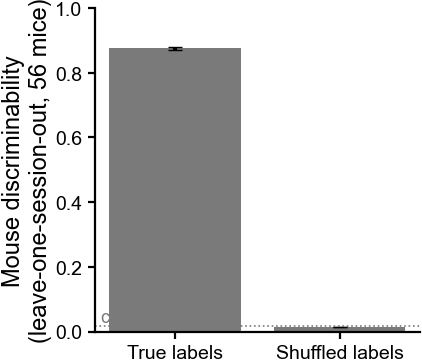

In [7]:
fig, ax = ps.figure('square', scale=0.6)
ax.bar(['True labels', 'Shuffled labels'],
       [true_scores.mean(), shuffle_scores.mean()],
       yerr=[true_scores.std() / np.sqrt(len(true_scores)),
             shuffle_scores.std() / np.sqrt(len(shuffle_scores))],
       color=ps.NEUTRAL, capsize=5)
ax.axhline(1 / N_MICE, color=ps.NEUTRAL, ls=':', lw=1.2)
ax.text(-0.45, 1 / N_MICE, 'chance ', ha='left', va='bottom',
        color=ps.NEUTRAL, fontsize=plt.rcParams['font.size'] * 0.8)
ax.set_ylabel(f'Mouse discriminability\n(leave-one-session-out, {N_MICE} mice)')
ax.set_ylim(0, 1)
ps.savefig(fig, 'lda_score_shrinkage', svg=True)
plt.show()

## Embedding — fit on all sessions

Deterministic: no balanced draw, so no draw-dependence. The old pipeline could not do this
safely because the leading discriminant eigenvalues are near-tied and each balanced draw
picked a different rotation within the same subspace (LD1 axes correlating 0.05 to 0.85
between draws). Shrinkage removes the draw entirely.

The per-session coordinates are written to `clustering/data_files/` as a **pickle** with the
schema the PCA pipeline used — columns `0..k`, `mouse_name`, `mouse_number`, `lab`,
`lab_number`, `session`, `binned1..binned5` — because every downstream notebook reads them
with `pd.read_pickle`.

**Known limitation, unchanged:** sessions per mouse are unequal (3 to 16), so mice with more
sessions weigh more in the pooled within-class scatter, and mice with fewer get noisier —
therefore more extreme — class means.

In [15]:
# ALL C-1 discriminants, not a round number. The saved frame's coordinate columns are
# 0..n_components-1, and downstream notebooks index them positionally; the PCA pipeline's
# count varied with min_components (25, 30, 40, 55 across existing files), so keeping the
# full 55 makes this frame a superset of every one of them and no consumer can ask for a
# column that is missing.
lda = fit_lda(X, y, BEST_SHRINKAGE, n_components=N_MICE - 1)
# CENTRE THE EMBEDDING BY HAND. sklearn's `transform` centres the data for solver='svd'
#     X_new = (X - self.xbar_) @ self.scalings_
# but NOT for solver='eigen', which we need for shrinkage:
#     X_new = X @ self.scalings_
# so the eigen embedding carries an arbitrary offset -- measured here, LD1 ran -30.15 to
# -4.85 instead of straddling zero. That silently breaks anything keyed to the sign or to
# zero: ps.ld1_colors is a diverging map symmetric about 0, so every mouse landed on one
# half of it, and the scatter's axvline(0)/axhline(0) become meaningless reference lines.
# Subtracting the grand mean -- the unweighted mean of the class means, which is what
# uniform priors make xbar_ -- reproduces the svd convention the PCA pipeline used and the
# downstream notebooks expect.
_grand = lda.means_.mean(axis=0)
embedding = ((X - _grand) @ lda.scalings_)[:, :N_MICE - 1]

# SHARE OF BETWEEN-MOUSE VARIANCE PER AXIS -- deliberately NOT
# lda.explained_variance_ratio_, which does not sum to 1 and is not interpretable here.
# sklearn divides each eigenvalue by the sum over ALL n_features dimensions, and with
# shrinkage the between-class scatter S_B = S_T - S_W picks up an isotropic term that makes
# every one of the 360 eigenvalues non-zero. Measured on this fit: the 55 real discriminants
# carry 0.218 of that sum (0.147 for the 30 kept here), and the largest DISCARDED eigenvalue
# (2.728) is indistinguishable from the smallest KEPT one (2.733). The ratio is therefore a
# property of the shrinkage floor, not of the mice.
#
# This reports instead how much of the between-mouse variance SPANNED BY THE PLOTTED AXES
# each axis carries, every mouse weighted equally. It sums to 1 by construction. Caveat:
# discriminant axes are not orthogonal in the data space, so it is a descriptive split
# rather than an exact variance decomposition.
_mouse_means = pd.DataFrame(embedding).groupby(y).mean()
between_var = _mouse_means.var(axis=0, ddof=0).to_numpy()
axis_share = between_var / between_var.sum()

print(f'embedding fit on all {len(X)} sessions, {N_MICE} mice, shrinkage {BEST_SHRINKAGE}')
print('between-mouse variance share (top 6):', np.round(axis_share[:6], 3))
print('  near-equal values mean those axes are free to rotate among themselves; treat '
      'them as a subspace, not as individual axes')

# THE SCHEMA IS FIXED BY THE DOWNSTREAM NOTEBOOKS, NOT BY THIS ONE. lda_trajectories,
# lda_pred, whisk_state_timepoints, engagement_trial_modes and the rest all do
#     pd.read_pickle(data_path + '<name>')
# and then index columns 0..k, 'mouse_name', 'mouse_number', 'lab', 'lab_number',
# 'session' and 'binned1'..'binned5'. Writing parquet, or dropping any of those columns,
# breaks every one of them -- so all of them are written whether or not this run uses them.
clustered = pd.DataFrame(embedding)
clustered['mouse_name'] = mouse_names.to_numpy()
clustered['mouse_number'] = pd.factorize(clustered['mouse_name'])[0]
clustered['lab'] = list(lab_of_session)
clustered['lab_number'] = pd.factorize(clustered['lab'])[0]
clustered['session'] = session_feats.index.to_numpy()
for _b in range(5):
    clustered[f'binned{_b + 1}'] = pd.cut(clustered[_b], 5)

if SAVE_EMBEDDING:
    # THE NAME IS DERIVED FROM THE KNOBS, NEVER TYPED -- the PCA pipeline once wrote two
    # byte-identical files three minutes apart, only one of them saying it was lab-corrected.
    _tag = ''
    if LAB_CORRECTION not in (None, 'none'):
        _tag += f'_lab{LAB_CORRECTION}'
    if FEATURE_NORM not in (None, 'none'):
        _tag += f'_norm{FEATURE_NORM}'
    if not _tag:
        _tag = '_raw'      # say "uncorrected" out loud; an absent tag is ambiguous with
                           # files written before the tag existed
    # The slot that held the PCA component count now holds the FEATURE count, and the
    # shrinkage goes in the tag, so a shrinkage file can never be read as a PCA one.
    data_path = _root / 'clustering' / 'data_files'
    filename = (f'mouse_LDA_5_bins{_tag}_shrink{BEST_SHRINKAGE}_{X.shape[1]}'
                f'_{datetime.now().strftime("%d-%m-%Y")}')
    clustered.to_pickle(data_path / filename)
    print(f'saved {data_path / filename}')
    print(f'  {clustered.shape[0]} rows x {clustered.shape[1]} cols; '
          f'tail columns {list(clustered.columns[-10:])}')

embedding fit on all 260 sessions, 56 mice, shrinkage 0.5
explained_variance_ratio_ (top 6): [0.014 0.01  0.01  0.01  0.008 0.006]
  near-equal leading values mean those axes are free to rotate among themselves; treat them as a subspace, not as individual axes
saved /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/clustering/data_files/lda_shrink0.5_pwl_lab-none_22-09-2026


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/io/parquet.py:190: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


## Mice in the LDA space

One point per mouse, coloured by its LD1 position. Sessions are drawn underneath as small
dots in their mouse's colour, so the spread the error bars summarise is visible directly.
Error bars are each mouse's own SEM, using its actual session count rather than a fixed
$\sqrt{4}$.

Axis labels report each axis's **share of the between-mouse variance spanned by the plotted
axes**, not sklearn's `explained_variance_ratio_`. With shrinkage that attribute does not sum
to 1 and is not interpretable — it normalises by a sum over all 360 feature dimensions, and
the shrinkage term makes every one of them non-zero, so the 55 real discriminants account for
only 0.218 of it. See the embedding cell.

Near-equal shares mean those axes are free to rotate among themselves — treat them as a
subspace, not as individual axes. Here LD4 (10.4%) outranks LD2 (9.2%) and LD3 (9.3%), which
is exactly that degeneracy showing.

wrote figures/lda12_mice_shrinkage_poster_22-09-2026.png, figures/lda12_mice_shrinkage_poster_22-09-2026.svg


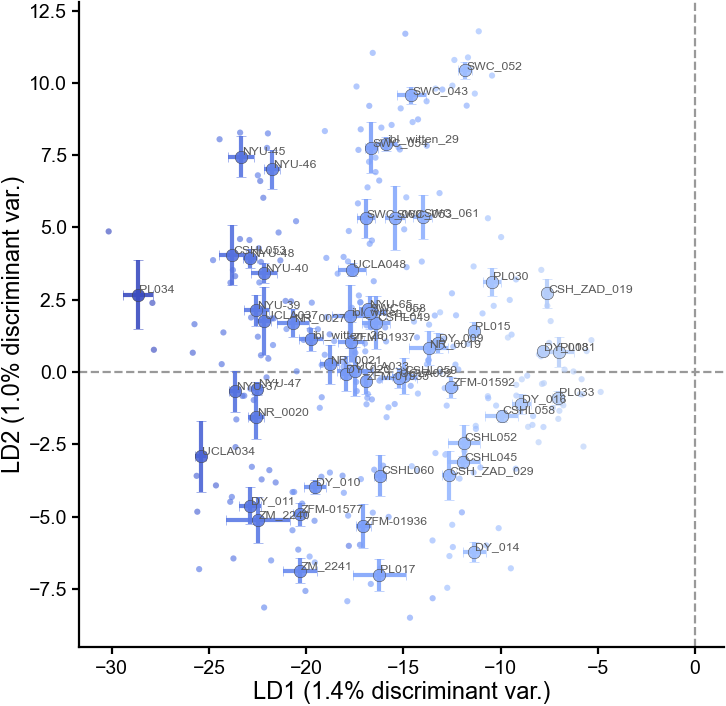

In [9]:
SHOW_LABELS = True
SHOW_SESSIONS = True

grouped = clustered.groupby('mouse_name')
mouse_means = grouped[[0, 1, 2]].mean()
mouse_sems = grouped[[0, 1, 2]].std().div(np.sqrt(grouped.size()), axis=0)
colors = ps.ld1_colors(mouse_means[0].values)


def ld_label(k):
    return f'LD{k + 1} ({100 * axis_share[k]:.1f}% of between-mouse var.)'


fig, ax = ps.figure('single', scale=1.5)

if SHOW_SESSIONS:
    cmap = dict(zip(mouse_means.index, colors))
    ax.scatter(clustered[0], clustered[1],
               c=np.array([cmap[m] for m in clustered['mouse_name']]),
               s=20, alpha=0.65, linewidths=0, zorder=1)

for mouse, cvec in zip(mouse_means.index, colors):
    mean_vals, sem_vals = mouse_means.loc[mouse], mouse_sems.loc[mouse]
    ax.errorbar(mean_vals[0], mean_vals[1], xerr=sem_vals[0], yerr=sem_vals[1],
                fmt='o', color=cvec, ecolor=cvec, alpha=0.9,
                markeredgecolor='0.25', markeredgewidth=0.4, zorder=2)
    if SHOW_LABELS:
        ax.text(mean_vals[0] + 0.05, mean_vals[1] + 0.05, str(mouse),
                fontsize=plt.rcParams['font.size'] * 0.55, color='0.35', zorder=3)

ax.axvline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
ax.axhline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
ax.set_box_aspect(1)
ax.set_xlabel(ld_label(0))
ax.set_ylabel(ld_label(1))
fig.tight_layout()
ps.savefig(fig, 'lda12_mice_shrinkage', svg=True)
plt.show()

## Feature importance — per-timestep correlation with an LD axis

Structural coefficients: the correlation between each original feature and the sessions'
positions on one discriminant. The shuffled band is the 95% null for $r$ at that timestep, so
a trace inside it is indistinguishable from chance. The trace is drawn twice — faint
everywhere, full strength only outside the band — so significant excursions are the only
solid ink.

Paw state 1 was dropped from the design matrix as the one-hot reference; it is reconstructed
here as $1 - \sum(\text{other 7 paw probabilities})$ so all 8 states are shown.

channels ('paw', 'whisk', 'lick'): 40 timesteps x 9 features
wrote figures/lda3_feature_importance_shrinkage_poster_22-09-2026.png, figures/lda3_feature_importance_shrinkage_poster_22-09-2026.svg


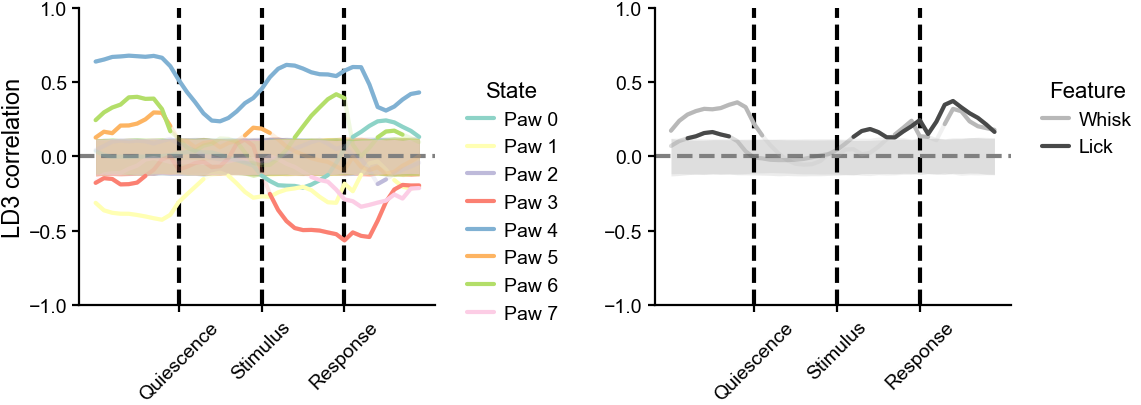

In [12]:
COMPONENT_TO_PLOT = 2        # 0-indexed: 0 is LD1
N_PERMS = 1000
ALPHA_IN_BAND = 0.2

scores_1d = embedding[:, COMPONENT_TO_PLOT]
feats = np.asarray(session_feats)      # ORIGINAL features, not the corrected ones

# The layout is derived from SYLLABLE_CHANNELS, never assumed.
HAS_PAW = 'paw' in SYLLABLE_CHANNELS
HAS_WHISK = 'whisk' in SYLLABLE_CHANNELS
HAS_LICK = 'lick' in SYLLABLE_CHANNELS
n_paw_cols = (N_PAW_STATES - 1) if HAS_PAW else 0
per_step = n_paw_cols + int(HAS_WHISK) + int(HAS_LICK)
timesteps = feats.shape[1] // per_step
assert timesteps * per_step == feats.shape[1], (
    f'{feats.shape[1]} features do not divide into {per_step} per timestep '
    f'for channels {SYLLABLE_CHANNELS}')
print(f'channels {SYLLABLE_CHANNELS}: {timesteps} timesteps x {per_step} features')


def colwise_pearsonr(M, v):
    """Per-column Pearson r between each column of M and the vector v."""
    Mc = M - M.mean(axis=0, keepdims=True)
    vc = v - v.mean()
    return (Mc.T @ vc) / (np.sqrt((Mc ** 2).sum(axis=0)) * np.sqrt((vc ** 2).sum()))


struct = colwise_pearsonr(feats, scores_1d).reshape(timesteps, per_step)

# Paw state 1 was dropped from the design matrix as the one-hot reference. Reconstruct it
# as 1 - the other 7 paw probabilities and correlate that series, so all 8 states are shown.
if HAS_PAW:
    omitted = 1 - feats.reshape(-1, timesteps, per_step)[:, :, :n_paw_cols].sum(axis=2)
    paw_full = np.zeros((timesteps, N_PAW_STATES))
    paw_full[:, 0] = struct[:, 0]
    paw_full[:, 1] = colwise_pearsonr(omitted, scores_1d)
    paw_full[:, 2:] = struct[:, 1:n_paw_cols]

# Null: permute which LD score belongs to which session and recompute the same profiles.
perm_rng = np.random.default_rng(0)
shuf = np.zeros((N_PERMS, timesteps, per_step))
shuf_omitted = np.zeros((N_PERMS, timesteps))
for p in range(N_PERMS):
    v = perm_rng.permutation(scores_1d)
    shuf[p] = colwise_pearsonr(feats, v).reshape(timesteps, per_step)
    if HAS_PAW:
        shuf_omitted[p] = colwise_pearsonr(omitted, v)

if HAS_PAW:
    shuf_paw = np.zeros((N_PERMS, timesteps, N_PAW_STATES))
    shuf_paw[:, :, 0] = shuf[:, :, 0]
    shuf_paw[:, :, 1] = shuf_omitted
    shuf_paw[:, :, 2:] = shuf[:, :, 1:n_paw_cols]
    paw_lo, paw_hi = np.percentile(shuf_paw, [2.5, 97.5], axis=0)
if HAS_WHISK:
    whisk_lo, whisk_hi = np.percentile(shuf[:, :, n_paw_cols], [2.5, 97.5], axis=0)
if HAS_LICK:
    lick_lo, lick_hi = np.percentile(shuf[:, :, n_paw_cols + int(HAS_WHISK)],
                                     [2.5, 97.5], axis=0)

time_axis = np.arange(timesteps)


def draw(ax, values, lo, hi, color, label, band_alpha):
    ax.fill_between(time_axis, lo, hi, color=color, alpha=band_alpha, lw=0, zorder=1)
    ax.plot(time_axis, values, color=color, lw=3, alpha=ALPHA_IN_BAND, zorder=2)
    outside = np.where((values >= lo) & (values <= hi), np.nan, values)
    ax.plot(time_axis, outside, color=color, lw=3, alpha=1.0, label=label, zorder=3)


panels = (['paw'] if HAS_PAW else []) + (['wl'] if (HAS_WHISK or HAS_LICK) else [])
fig, axs = plt.subplots(1, len(panels), figsize=(6 * len(panels), 4.5), squeeze=False)
axs = axs[0]

for ax in axs:
    for x in (10, 20, 30):
        ax.axvline(x, color='k', ls='--')
    ax.axhline(0, color='grey', ls='--')
    ax.set_xticks([10, 20, 30])
    ax.set_xticklabels(['Quiescence', 'Stimulus', 'Response'], rotation=45)
    ax.set_ylim(-1, 1)

if HAS_PAW:
    ax_paw = axs[panels.index('paw')]
    palette = sns.color_palette('Set3', N_PAW_STATES)
    for state in range(N_PAW_STATES):
        draw(ax_paw, paw_full[:, state], paw_lo[:, state], paw_hi[:, state],
             palette[state], f'Paw {state}', 0.5)
    ax_paw.set_ylabel(f'LD{COMPONENT_TO_PLOT + 1} correlation')
    ax_paw.legend(title='State', bbox_to_anchor=(1.05, 0.8), loc='upper left')

if HAS_WHISK or HAS_LICK:
    ax_wl = axs[panels.index('wl')]
    if HAS_WHISK:
        draw(ax_wl, struct[:, n_paw_cols], whisk_lo, whisk_hi, '#b8b8b8', 'Whisk', 0.2)
    if HAS_LICK:
        draw(ax_wl, struct[:, n_paw_cols + int(HAS_WHISK)], lick_lo, lick_hi,
             '#484949', 'Lick', 0.1)
    if not HAS_PAW:
        ax_wl.set_ylabel(f'LD{COMPONENT_TO_PLOT + 1} correlation')
    ax_wl.legend(title='Feature', bbox_to_anchor=(1.05, 0.8), loc='upper left')

fig.tight_layout()
ps.savefig(fig, f'lda{COMPONENT_TO_PLOT + 1}_feature_importance_shrinkage', svg=True)
plt.show()